Generating URL ...
Please wait ...
Data downloaded to /home/rstudio/SIG_T1/Practica_11/data_heavy/raster/dem_nevado_ruiz_4326.tif
DEM descargado localmente
Raster reproyectado a EPSG:9377
Productos topográficos generados


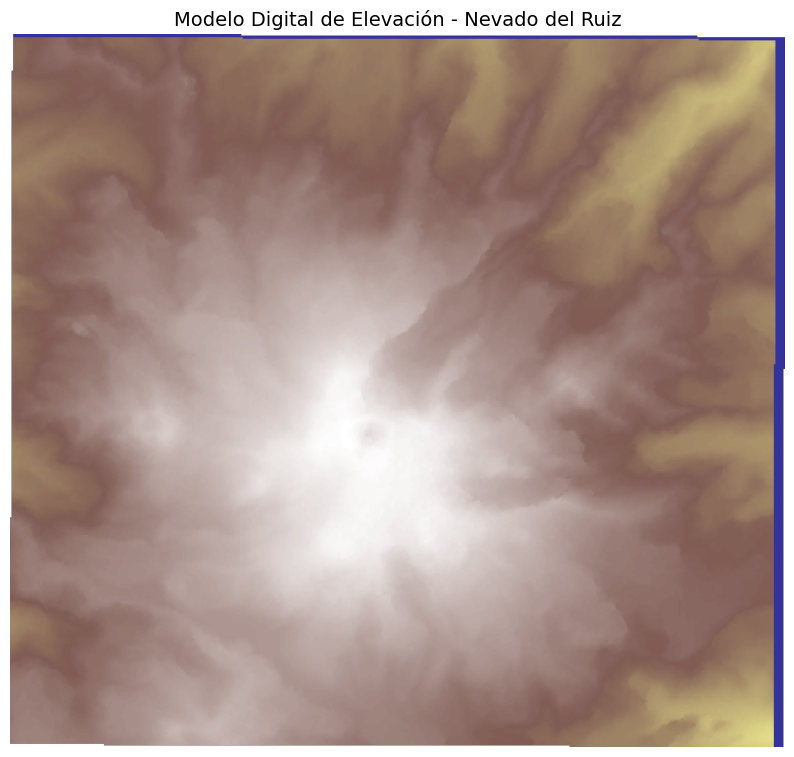

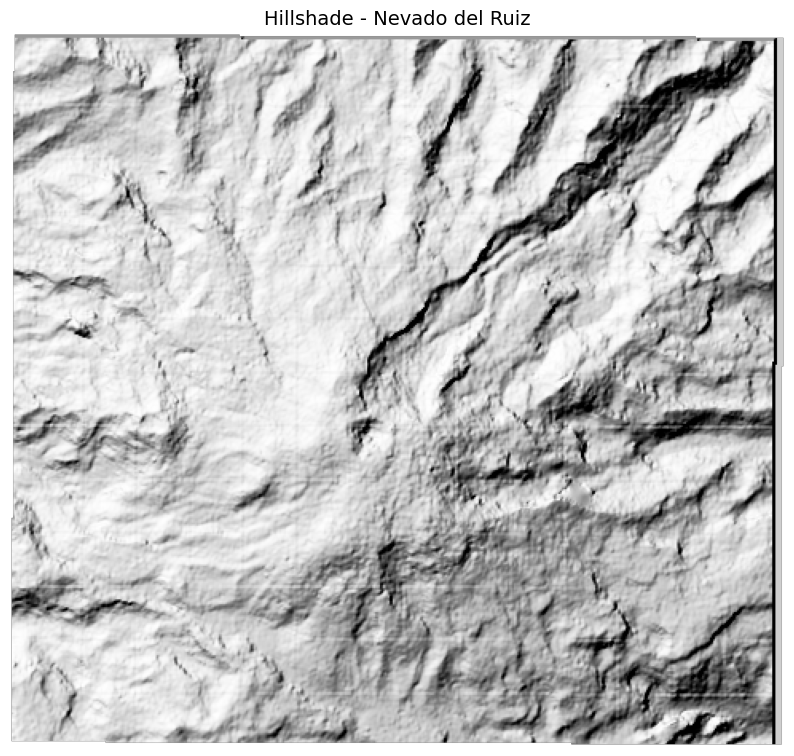

In [9]:
# =========================================================================
# VOLCÁN NEVADO DEL RUIZ - MDE SRTM + HILLSHADE
# GOOGLE EARTH ENGINE + GDAL + RASTERIO
# =========================================================================

# -------------------------------------------------------------------------
# 1. LIBRERÍAS
# -------------------------------------------------------------------------

import ee
import geemap

from osgeo import gdal
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 2. AUTENTICACIÓN E INICIALIZACIÓN GEE
# -------------------------------------------------------------------------

# Ejecutar solo la primera vez
ee.Authenticate()

# Inicializar Earth Engine
ee.Initialize()

# -------------------------------------------------------------------------
# 3. DEFINICIÓN DEL ÁREA DE ESTUDIO
# -------------------------------------------------------------------------

# Coordenadas del Cráter Arenas
lon = -75.319
lat = 4.892

# Punto central
centro = ee.Geometry.Point([lon, lat])

# Área de 15x15 km
area_estudio = centro.buffer(7500).bounds()

# Bounding Box del edificio volcánico
volcan_bbox = ee.Geometry.Rectangle([
    -75.38, 4.84,   
    -75.25, 4.96    
])

# -------------------------------------------------------------------------
# 4. DESCARGA DEL MDE SRTM DESDE GEE
# -------------------------------------------------------------------------

# Modelo Digital de Elevación SRTM
srtm = ee.Image("USGS/SRTMGL1_003")

# Recorte inicial
dem = srtm.clip(area_estudio)

# Clip final al edificio volcánico
dem_volcan = dem.clip(volcan_bbox)

# -------------------------------------------------------------------------
# 5. EXPORTACIÓN LOCAL DEL RASTER
# -------------------------------------------------------------------------

import os

# Crear directorios
os.makedirs("data_heavy/raster", exist_ok=True)

ruta_mde_4326 = "data_heavy/raster/dem_nevado_ruiz_4326.tif"

# Exportar desde Earth Engine
geemap.ee_export_image(
    dem_volcan,
    filename=ruta_mde_4326,
    scale=30,
    region=volcan_bbox,
    file_per_band=False
)

print("DEM descargado localmente")
# -------------------------------------------------------------------------
# 6. REPROYECCIÓN A MAGNA-SIRGAS ORIGEN NACIONAL (EPSG:9377)
# -------------------------------------------------------------------------

ruta_mde_9377 = "data_heavy/raster/dem_nevado_ruiz_9377.tif"

# Reproyección
ds_warp = gdal.Warp(
    ruta_mde_9377,
    ruta_mde_4326,
    dstSRS="EPSG:9377"
)

# Cerrar archivo y liberar memoria
ds_warp = None

print("Raster reproyectado a EPSG:9377")

# -------------------------------------------------------------------------
# 7. PRODUCTOS TOPOGRÁFICOS
# -------------------------------------------------------------------------

ruta_pendiente = "data_heavy/raster/dem_nevado_ruiz_slope.tif"
ruta_orientacion = "data_heavy/raster/dem_nevado_ruiz_aspect.tif"
ruta_sombreado = "data_heavy/raster/dem_nevado_ruiz_hillshade.tif"

# ---------------------------------------------------------
# Pendiente (Slope)
# ---------------------------------------------------------

ds_slope = gdal.DEMProcessing(
    ruta_pendiente,
    ruta_mde_9377,
    "slope"
)

ds_slope = None

# ---------------------------------------------------------
# Orientación (Aspect)
# ---------------------------------------------------------

ds_aspect = gdal.DEMProcessing(
    ruta_orientacion,
    ruta_mde_9377,
    "aspect"
)

ds_aspect = None

# ---------------------------------------------------------
# Hillshade
# Azimut = 315°
# Altitud solar = 45°
# ---------------------------------------------------------

ds_hill = gdal.DEMProcessing(
    ruta_sombreado,
    ruta_mde_9377,
    "hillshade",
    azimuth=315,
    altitude=45
)

ds_hill = None

print("Productos topográficos generados")


# -------------------------------------------------------------------------
# 8. VISUALIZACIÓN CARTOGRÁFICA
# PRODUCTOS POR SEPARADO
# -------------------------------------------------------------------------

# =========================================================
# MAPA 1: MODELO DIGITAL DE ELEVACIÓN (MDE)
# =========================================================

with rasterio.open(ruta_mde_9377) as mde_src:

    fig, ax = plt.subplots(figsize=(10, 10))

    # Mostrar DEM
    show(
        mde_src,
        ax=ax,
        cmap='terrain'
    )

    # Configuración cartográfica
    ax.set_title(
        "Modelo Digital de Elevación - Nevado del Ruiz",
        fontsize=14
    )

    ax.set_axis_off()

    plt.show()

# =========================================================
# MAPA 2: HILLSHADE
# =========================================================

with rasterio.open(ruta_sombreado) as hill_src:

    fig, ax = plt.subplots(figsize=(10, 10))

    # Mostrar Hillshade
    show(
        hill_src,
        ax=ax,
        cmap='Greys_r'
    )

    # Configuración cartográfica
    ax.set_title(
        "Hillshade - Nevado del Ruiz",
        fontsize=14
    )

    ax.set_axis_off()

    plt.show()